<a href="https://colab.research.google.com/github/Muqtarali/Deep-Learning/blob/main/Perceptron/Perceptron_Loss_Function_%7C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=15)
# Convert y from {0, 1} to {-1, 1} for the perceptron algorithm
y = np.where(y == 0, -1, 1)

In [16]:
X.shape



(100, 2)

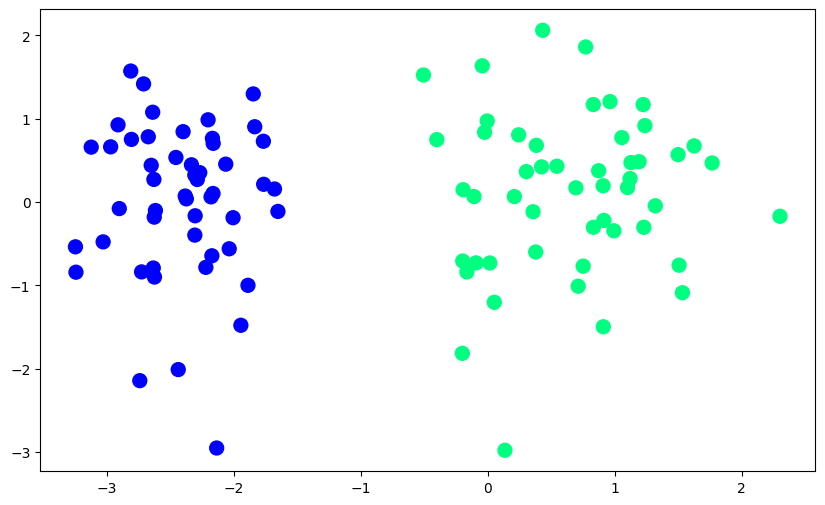

In [17]:
y.shape

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [18]:
def perceptron(X,y):

    w1=w2=b=1
    lr = 0.1

    for j in range(1000):

        for i in range(X.shape[0]):

            # check condition
            z = w1*X[i][0] + w2*X[i][1] + b

            if z*y[i] < 0:
                w1 = w1 + lr*y[i]*X[i][0]
                w2 = w2 + lr*y[i]*X[i][1]
                b = b + lr*y[i]

    return w1,w2,b

In [19]:
w1,w2,b=perceptron(X,y)

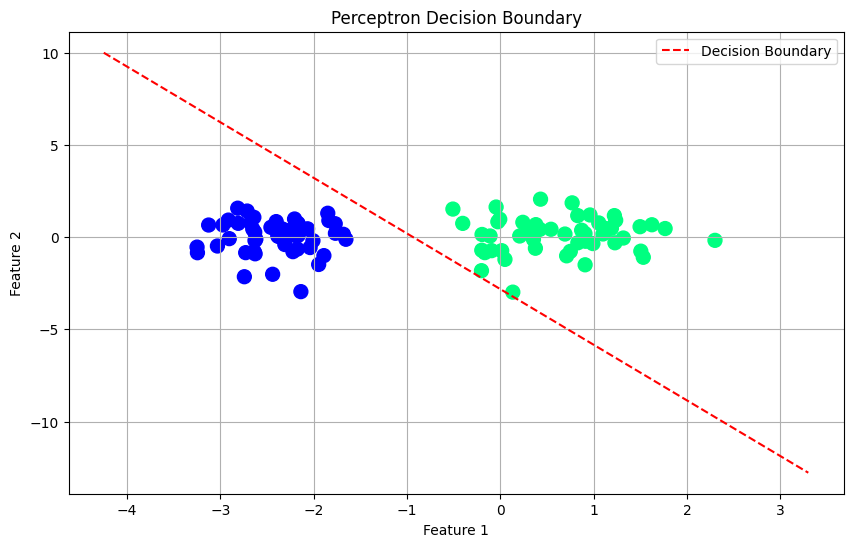

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

# Plot the decision boundary
# The decision boundary is w1*x1 + w2*x2 + b = 0
# So, x2 = (-w1*x1 - b) / w2
x1_min, x1_max = X[:,0].min() - 1, X[:,0].max() + 1
x2_min, x2_max = X[:,1].min() - 1, X[:,1].max() + 1

# Create a range of x1 values
x1_plot = np.linspace(x1_min, x1_max, 100)

# Calculate corresponding x2 values for the decision boundary
# Handle the case where w2 might be very close to zero to avoid division by zero
if w2 != 0:
    x2_plot = (-w1 * x1_plot - b) / w2
else:
    # If w2 is zero, the boundary is a vertical line: w1*x1 + b = 0 => x1 = -b/w1
    x2_plot = np.linspace(x2_min, x2_max, 100) # Use the range of x2 for plotting
    x1_plot = np.full_like(x2_plot, -b / w1) # x1 is constant

plt.plot(x1_plot, x2_plot, color='red', linestyle='--', label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()